In [62]:
import numpy as np
import pandas as pd
import thinkbayes

In [63]:
df = pd.read_csv("showcases.2011.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df1 = df.copy()

df = pd.read_csv("showcases.2012.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df2 = df.copy()

df3 = pd.concat([df1, df2], axis=0, ignore_index=True)

In [64]:
showcase1 = df3["Showcase 1"].dropna().values
showcase2 = df3["Showcase 2"].dropna().values

diff1 = df3["Difference 1"].to_numpy()
diff2 = df3["Difference 2"].to_numpy()

bid1 = df3["Bid 1"].dropna().values
bid2 = df3["Bid 2"].dropna().values

In [65]:
class Player(object):
    """Represents a player on The Price is Right."""

    n = 101
    price_xs = np.linspace(0, 75000, n)

    def __init__(self, prices, bids, diffs):
        """Construct the Player.
        Prices: sequence of prices
        bids: sequence of bids
        diffs: sequence of underness (negative means over)
        """

        self.pdf_price = thinkbayes.EstimatedPdf(prices)
        self.cdf_diff = thinkbayes.MakeCdfFromList(diffs)

        mu = 0
        sigma = np.std(diffs)
        self.pdf_error = thinkbayes.GaussianPdf(mu, sigma)

        self.pdf_error_kde = thinkbayes.EstimatedPdf(diffs)

    def ErrorDensity(self, error):
        """Density of the given error in the distribution of error.
        error: how much the bid in under the actual price
        """

        return self.pdf_error.Density(error)

    def PmfPrice(self):
        """Return a new pmf of prices.
        
        A discrete version of the estimated Pdf.
        """

        return self.pdf_price.MakePmf(self.price_xs)

    def CdfDiff(self):
        """Return a reference to the Cdf of differences (underness)."""

        return self.pdf_diff

    def ErrorDensityGauss(self, error):
        """Density of the given error in the distribution of error.
        
        error: how much the bid is under the actual price
        """
        return self.pdf_error_gauss.Density(error)

    def ErrorDensityKDE(self, error):
        return self.pdf_error_kde.Density(error)

    def MakeBeliefs(self, guess):
        """Makes a posterior distribution based on estimated price.
        Sets attributes prior and posterior.
        guess: what the player thinks the showcase is worth
        """

        pmf = self.PmfPrice()
        self.prior = Price(pmf, self, name='prior')
        self.posterior = self.prior.Copy(name='posterior')
        self.posterior.Update(guess)


In [66]:
class Price(thinkbayes.Suite):
    """Represents hypotheses about the price of a showcase."""

    def __init__(self, pmf, player, name=""):
        """Constructs the suite.
        
        pmf: prior distribution of price
        player: player object
        name: string
        """

        thinkbayes.Suite.__init__(self, pmf, name=name)
        self.player = player

    def Likelihood(self, data, hypo):
        """Computes the likelihood of the data under the hypothesis.
        
        hypo: actual price
        data: the contestant's guess
        """

        price = hypo
        guess = data

        error = price - guess
        like = self.player.ErrorDensity(error)

        return like


In [67]:
player1 = Player(showcase1, bid1, diff1)
player2 = Player(showcase2, bid2, diff2)

player1.MakeBeliefs(guess=20000)
player2.MakeBeliefs(guess=40000)

In [68]:
mean1 = player1.posterior.Mean()
mean2 = player2.posterior.Mean()

mle1 = player1.posterior.MaximumLikelihood()
mle2 = player2.posterior.MaximumLikelihood()

print(mean1, mean2)
print(mle1, mle2)

25096.41181620624 35641.21686971352
24000.0 35250.0


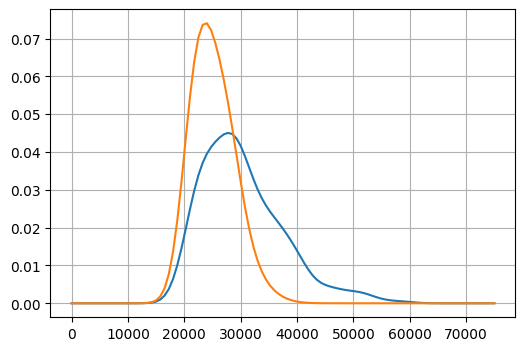

In [ ]:
import matplotlib.pyplot as plt

prior_x, prior_y = zip(*player1.prior.Items())
posterior_x, posterior_y = zip(*player1.posterior.Items())

plt.figure(figsize=(6,4))
plt.plot(prior_x, prior_y)
plt.plot(posterior_x, posterior_y)
plt.grid(True)
